**Calculating Greeks with finite difference vs the closed form analytical version**

This notebook compares finite difference approximations against analytical solutions for option Greeks to validate numerical accuracy. The error plots illustrate the trade-off between truncation error at larger step sizes and round-off error at smaller step sizes. The convergence of the two methods confirms the structural integrity of the bump-and-reprice implementation and helps establish an optimal bump size $h$ for production models.

In [23]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from src.option import Option

In [22]:
import importlib
importlib.reload(sys.modules['src.option'])

<module 'src.option' from 'c:\\Users\\wfpin\\Desktop\\Projects\\greeks\\notebooks\\..\\src\\option.py'>

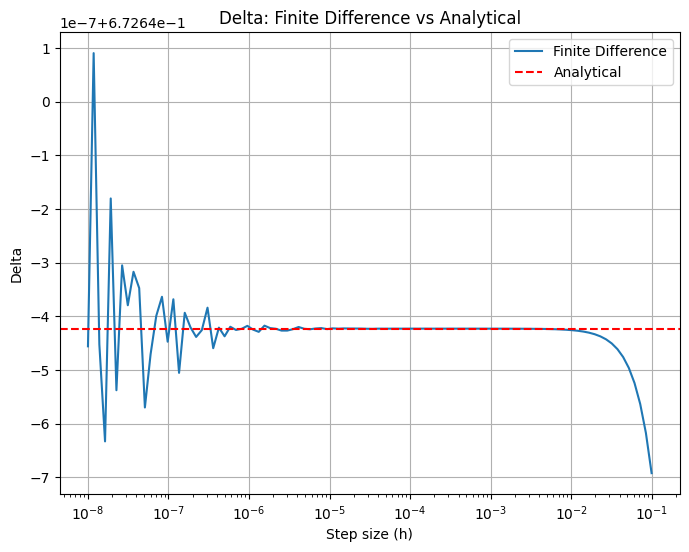

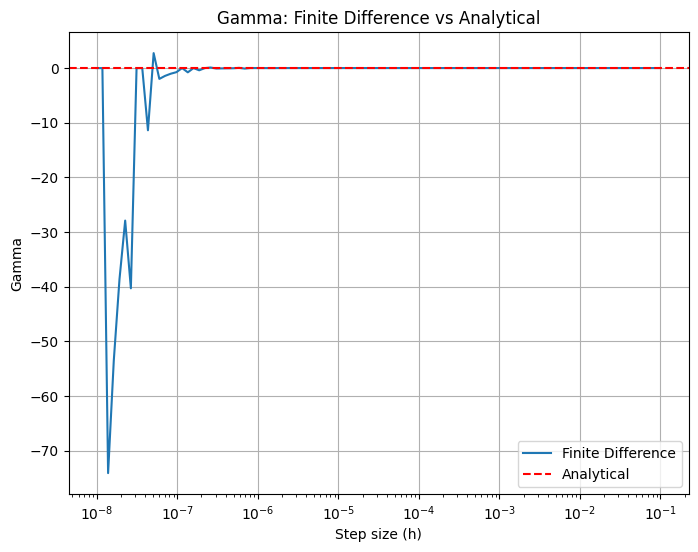

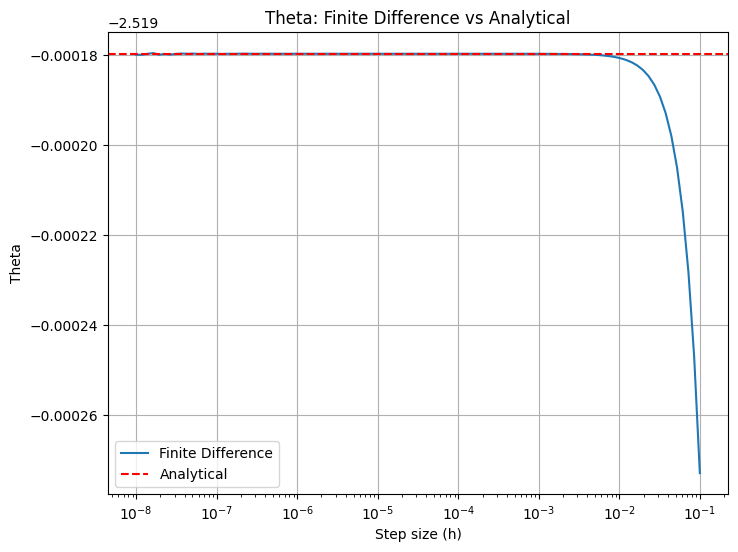

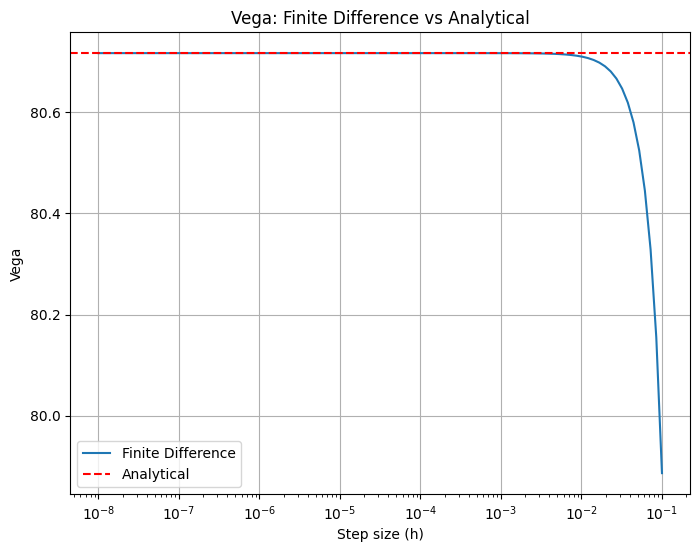

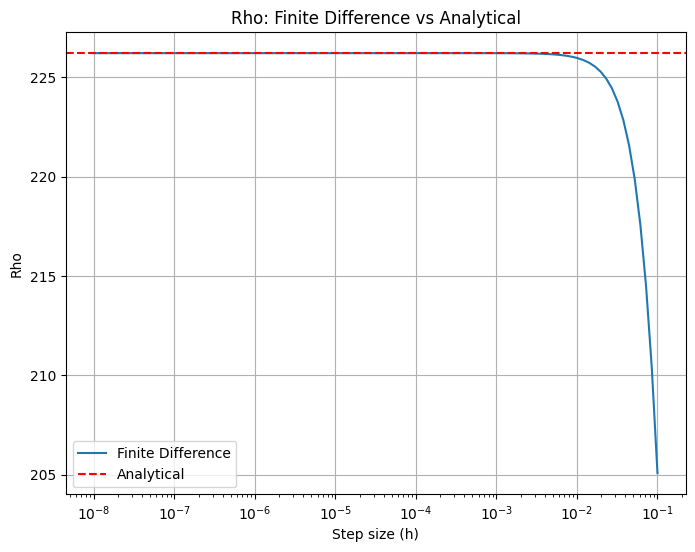

In [26]:
def plot_fd_vs_analytical(greek:str, S = 100, T = 5, r = 0.02, K = 100, sigma = 0.2):
    
    if greek not in ['delta', 'gamma', 'theta', 'vega', 'rho']:
        raise ValueError('Invalid greek')

    opt = Option(S=S, T=T, r=r, K=K, sigma=sigma)

    # Retrieve correct functions for the greek
    analytic_method = getattr(opt, greek)
    fd_method = getattr(opt, f'finite_diff_{greek}')

    # 3. Compute values
    analytic = analytic_method()  # Calls opt.delta(), opt.gamma(), etc
    
    hs = np.logspace(-8, -1, 100)
    fd = [fd_method(h) for h in hs]  # Calls opt.finite_diff_delta(h), etc

    # Plot
    plt.figure(figsize=(8,6))
    plt.plot(hs, fd, label='Finite Difference')
    plt.axhline(
        y=analytic,
        color='red',
        linestyle='--',
        label='Analytical'
    )

    plt.xscale('log')
    plt.xlabel('Step size (h)')
    plt.ylabel(greek.capitalize())
    plt.title(f'{greek.capitalize()}: Finite Difference vs Analytical')
    plt.legend()
    plt.grid(True)

for greek in ['delta', 'gamma', 'theta', 'vega', 'rho']:
    plot_fd_vs_analytical(greek)

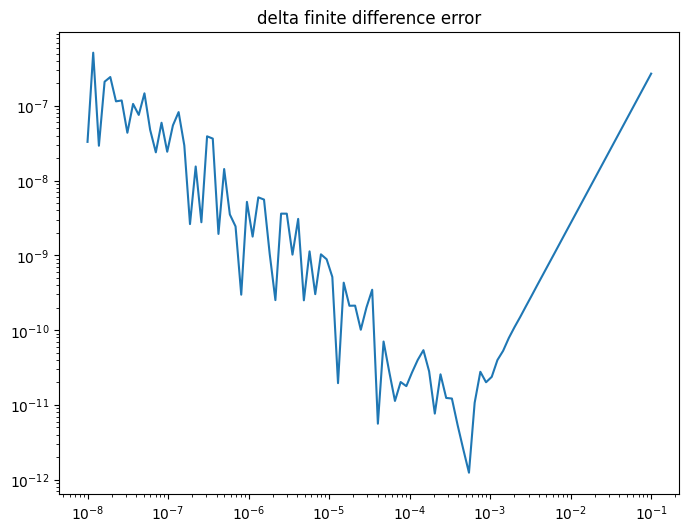

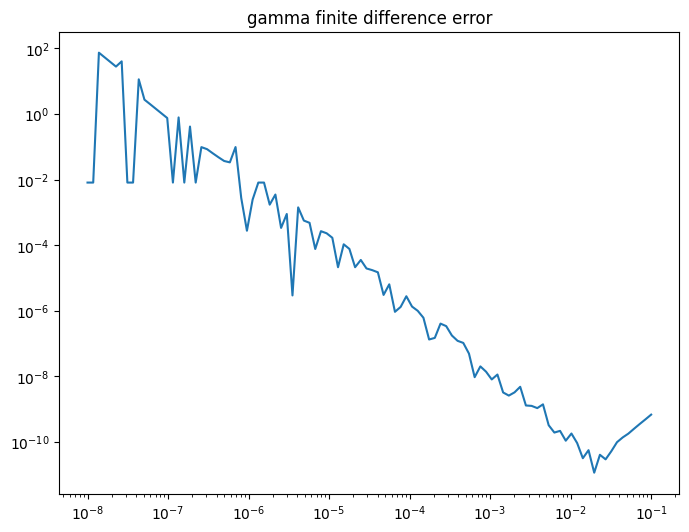

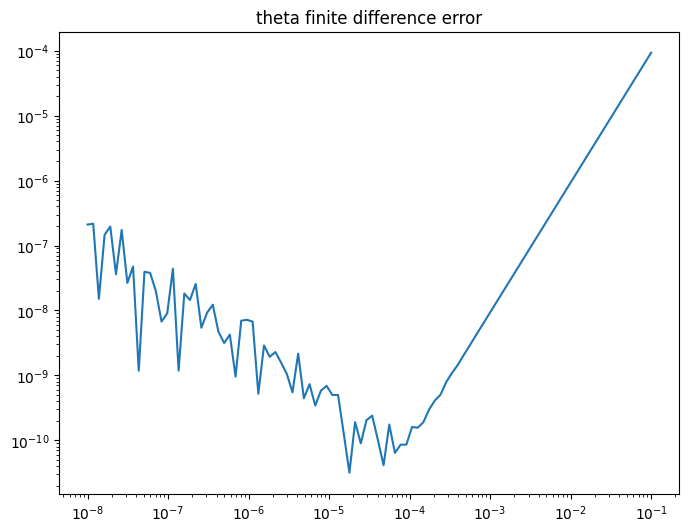

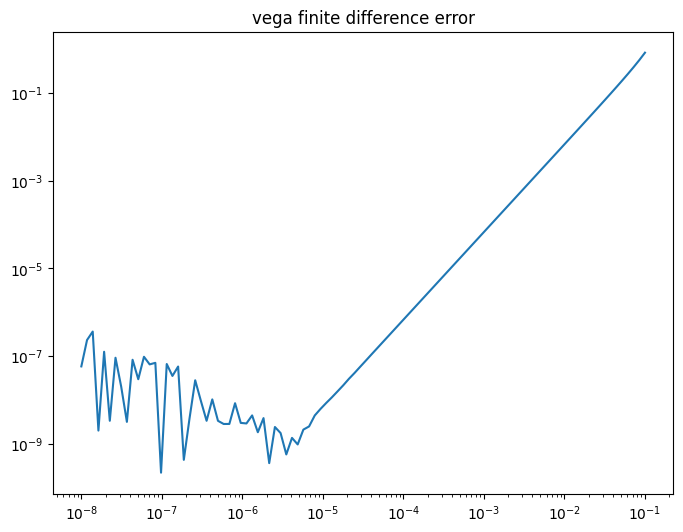

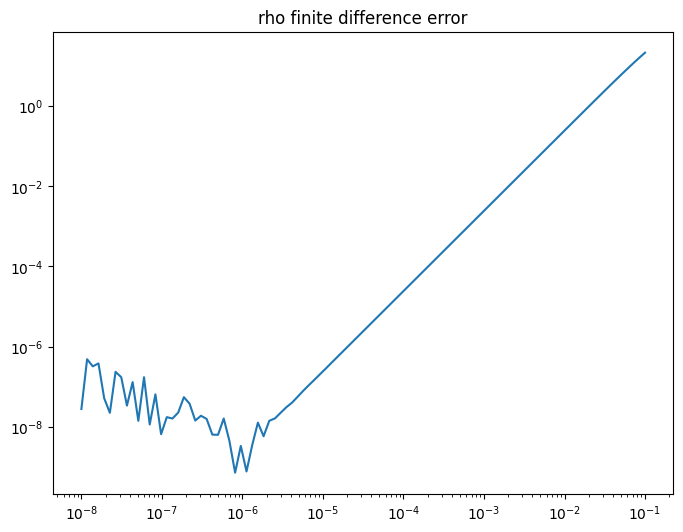

In [27]:
def plot_errors(greek, S=100, T=5, r=0.02, K=100, sigma=0.2):

    opt = Option(S, T, r, K, sigma)

    analytic = getattr(opt, greek)()

    hs = np.logspace(-8, -1, 100)

    fd = np.array([getattr(opt, f'finite_diff_{greek}')(h) for h in hs])

    error = np.abs(fd - analytic)

    plt.figure(figsize=(8,6))
    plt.plot(hs, error)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'{greek} finite difference error')
    plt.show()

for greek in ['delta', 'gamma', 'theta', 'vega', 'rho']:
    plot_errors(greek)